In [1]:
import leafmap
import rasterio
from eoflow.utils import HYDROSHEDS_DATA
from shapely import Point, box
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt

In [2]:
tif_path = HYDROSHEDS_DATA / "eu_msk_3s.tif"
assert tif_path.is_file()

In [3]:
center = Point((50.7260, -3.52756))

# define range
lat_range, long_range = 0.2, 0.4

# generate quadrant
quad = box(
    center.y - long_range, center.x - lat_range,
    center.y + long_range, center.x + lat_range
)

In [4]:
with rasterio.open(tif_path) as src:
    window = from_bounds(*quad.bounds, src.transform)
    data = src.read(1, window=window)

(480, 960)


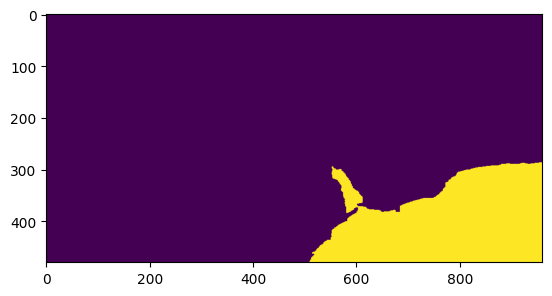

In [5]:
print(data.shape)
plt.imshow(data)

In [6]:
crop_file = "eu_msk_3s_crop.tif"

# Your crop bounds (lon/lat)
xmin, ymin, xmax, ymax = quad.bounds   # <— if you're using a shapely box

with rasterio.open(tif_path) as src:
    window = from_bounds(xmin, ymin, xmax, ymax, src.transform)
    data = src.read(1, window=window)
    transform = rasterio.windows.transform(window, src.transform)

    profile = src.profile
    profile.update({
        "height": data.shape[0],
        "width": data.shape[1],
        "transform": transform,
    })

with rasterio.open(crop_file, "w", **profile) as dst:
    dst.write(data, 1)

In [7]:

m = leafmap.Map(
    center=center.coords[0],
    zoom=10.,
    height="500px", 
    width="800px",
    scroll_wheel_zoom=False, 
)

In [8]:

m.add_raster(
    crop_file,
    palette=["white", "blue"],  # 0 → transparent, 1 → blue
    opacity=0.8,
    layer_name="rivers"
)

# m.add_basemap("OpenStreetMap")


In [9]:
m.add_layer_control()

In [10]:
m

Map(center=[50.726, -3.5275600000000003], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_…

In [11]:
import geopandas as gpd
import fiona
gdb_path = "/home/finley/Work/RDS/projects/enforce/data/HydroSHEDS/HydroRIVERS_v10_eu.gdb"
fiona.listlayers(gdb_path)


['HydroRIVERS_v10_eu']

In [12]:

layer_name = "HydroRIVERS_v10_eu"  # You may need to list layers first

gdf = gpd.read_file(gdb_path, layer=layer_name)
gdf.columns

Index(['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM',
       'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS',
       'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'Shape_Length',
       'geometry'],
      dtype='object')

In [13]:
gdf["geometry"]

0         MULTILINESTRING ((59.2625 81.78958, 59.30625 8...
1         MULTILINESTRING ((58.24167 81.77708, 58.13542 ...
2         MULTILINESTRING ((57.50833 81.51042, 57.44375 ...
3         MULTILINESTRING ((57.07917 81.50417, 57.06875 ...
4         MULTILINESTRING ((56.55208 81.33125, 56.54792 ...
                                ...                        
938539    MULTILINESTRING ((44.25625 12.66667, 44.25625 ...
938540    MULTILINESTRING ((44.05 12.67083, 44.05625 12....
938541    MULTILINESTRING ((44.04375 12.63333, 44.04375 ...
938542    MULTILINESTRING ((43.97708 12.6125, 43.97708 1...
938543    MULTILINESTRING ((44.02708 12.73125, 44.02708 ...
Name: geometry, Length: 938544, dtype: geometry

In [35]:
from shapely.geometry import Polygon

area = gpd.GeoDataFrame(geometry=[quad], crs=gdf.crs)

masked_rivers = gpd.overlay(gdf, area, how="intersection")

In [36]:
import folium

In [37]:
# Get the center of your area
m = folium.Map(
    location=[center.x, center.y], 
    zoom_start=10,
    scroll_wheel_zoom=False, 
    height="500px", 
    width="800px",
)

In [38]:
folium.GeoJson(
    area,
    name="Bounding Box",
    style_function=lambda x: {"color": "red", "weight": 2, "fill": False}
).add_to(m)

In [39]:
# Ensure your GeoDataFrame is in WGS84 (lat/lon)
masked_rivers = masked_rivers.to_crs("EPSG:4326")

# Add all masked rivers as a GeoJson layer
folium.GeoJson(
    masked_rivers,
    name="Rivers",
    style_function=lambda x: {"color": "blue", "weight": 2}
).add_to(m)

In [40]:
m

In [42]:
masked_rivers.to_file("hydro_rivers.gdf")